> # Notebook 3 — RT-DETR Training
Objectives

This notebook will:

Load the processed pothole dataset.
Install and configure the required dependencies.
Initialize the RT-DETR model.
Configure training hyperparameters.
Train the detector.
Save the best model weights.
Visualize training metrics.
Export the trained model for inference.

## Project
AI-Based Road Hazard Detection and Pothole Severity Assessment

### Objective

Train a single-class RT-DETR object detector using the processed pothole dataset generated in Notebook 1.

This notebook covers:

- Environment setup
- Dataset loading
- Model configuration
- Training
- Evaluation
- Model export

## Notebook 3 — RT-DETR Training

1. Project Setup
2. Install Dependencies
3. Import Libraries
4. Hardware Information
5. Load Dataset
6. Validate dataset.yaml
7. Initialize RT-DETR
8. Configure Training
9. Train Model
10. Analyze Training Results
11. Validate Best Model
12. Export Model
13. Conclusions

In [34]:
#Install Libraries & Depedencies
!pip install -q ultralytics

In [35]:
import ultralytics

print(ultralytics.__version__)

8.4.106


In [36]:
from ultralytics import checks
checks()

Ultralytics 8.4.106 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 7035.6/8062.4 GB disk)


In [37]:
from ultralytics import RTDETR

import os
import shutil
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
# GPU Information

import torch

print("="*60)
print("SYSTEM INFORMATION")
print("="*60)

print("PyTorch :", torch.__version__)

print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

SYSTEM INFORMATION
PyTorch : 2.10.0+cu128
CUDA Available : True
GPU : Tesla T4


In [39]:
from pathlib import Path
import yaml

DATASET = Path("/kaggle/input/datasets/krishnatheachiever/processed-pothole-yolo-dataset")

yaml_path = DATASET / "dataset.yaml"

with open(yaml_path) as f:
    cfg = yaml.safe_load(f)

# Update dataset root
cfg["path"] = str(DATASET)

# Save corrected yaml
fixed_yaml = "/kaggle/working/dataset_fixed.yaml"

with open(fixed_yaml, "w") as f:
    yaml.dump(cfg, f, sort_keys=False)

print(cfg)
print("\n✅ Fixed YAML saved to:", fixed_yaml)

{'path': '/kaggle/input/datasets/krishnatheachiever/processed-pothole-yolo-dataset', 'train': 'images/train', 'val': 'images/val', 'names': {0: 'pothole'}}

✅ Fixed YAML saved to: /kaggle/working/dataset_fixed.yaml


In [40]:
with open("/kaggle/working/dataset_fixed.yaml") as f:
    print(f.read())

path: /kaggle/input/datasets/krishnatheachiever/processed-pothole-yolo-dataset
train: images/train
val: images/val
names:
  0: pothole



In [41]:
from pathlib import Path
import yaml

DATASET = Path("/kaggle/input/datasets/krishnatheachiever/processed-pothole-yolo-dataset")

dataset_yaml = {
    "path": str(DATASET),
    "train": "images/train",
    "val": "images/val",
    "names": {
        0: "pothole"
    }
}

yaml_save_path = "/kaggle/working/dataset.yaml"

with open(yaml_save_path, "w") as f:
    yaml.dump(dataset_yaml, f, sort_keys=False)

print(f"Dataset YAML saved to: {yaml_save_path}")

Dataset YAML saved to: /kaggle/working/dataset.yaml


In [42]:
with open(yaml_save_path) as f:
    print(f.read())

path: /kaggle/input/datasets/krishnatheachiever/processed-pothole-yolo-dataset
train: images/train
val: images/val
names:
  0: pothole



| Model         | Parameters | Expected Training Time (100 epochs) | Kaggle GPU Memory |
| ------------- | ---------: | ----------------------------------: | ----------------: |
| **RT-DETR-m** |       ~31M |                   **1.5–2.5 hours** |           ~7–9 GB |
| **RT-DETR-l** |       ~42M |                     **2.5–4 hours** |         ~10–13 GB |
| **RT-DETR-x** |       ~76M |                       **5–8 hours** |         ~14–16 GB |

We've chosen RT-DETR-1 

In [43]:
from ultralytics import RTDETR

model = RTDETR("rtdetr-l.pt")

print("✅ Model loaded successfully.")

✅ Model loaded successfully.


## Proposed Training Configuration
| Parameter               |       Value | Reason                                                                                                         |
| ----------------------- | ----------: | -------------------------------------------------------------------------------------------------------------- |
| Image Size              |     **640** | Standard RT-DETR resolution; preserves detail while fitting comfortably in Kaggle GPU memory.                  |
| Epochs                  |     **100** | Sufficient for convergence on a ~5.8k image dataset; we can stop earlier if needed based on validation trends. |
| Batch Size              |      **16** | A good starting point for Kaggle's T4/L4 GPUs. If memory allows, we can increase it to 24 or 32.               |
| Optimizer               |   **AdamW** | Often provides stable convergence for transformer-based detectors like RT-DETR.                                |
| Initial Learning Rate   |    **1e-4** | Conservative and appropriate for fine-tuning pretrained transformer weights.                                   |
| Weight Decay            |  **0.0005** | Helps regularize the model and reduce overfitting.                                                             |
| Early Stopping Patience |      **20** | Stops training if validation performance plateaus, saving GPU time.                                            |
| Mixed Precision (AMP)   | **Enabled** | Reduces memory usage and speeds up training with negligible accuracy impact.                                   |
| Seed                    |      **42** | Ensures reproducible experiments.                                                                              |
| Workers                 |       **4** | Good balance for Kaggle's environment.                                                                         |


In [44]:
#Configuration
# ============================================================
# Experiment Configuration
# ============================================================

EXPERIMENT = {

    "name": "Baseline_RTDETR_L",

    "model": "rtdetr-l.pt",

    "data": "/kaggle/working/dataset_fixed.yaml",

    "epochs": 75,

    "imgsz": 640,

    "batch": 16,

    "optimizer": "auto",

    "lr0": 1e-4,

    "weight_decay": 5e-4,

    "patience": 15,

    "workers": 4,

    "device": 0,

    "seed": 42,

    "amp": True,

    "project": "RTDETR_Pothole",

    "verbose": True

}

EXPERIMENT

{'name': 'Baseline_RTDETR_L',
 'model': 'rtdetr-l.pt',
 'data': '/kaggle/working/dataset_fixed.yaml',
 'epochs': 75,
 'imgsz': 640,
 'batch': 16,
 'optimizer': 'auto',
 'lr0': 0.0001,
 'weight_decay': 0.0005,
 'patience': 15,
 'workers': 4,
 'device': 0,
 'seed': 42,
 'amp': True,
 'project': 'RTDETR_Pothole',
 'verbose': True}

In [46]:
print(f"Model: {EXPERIMENT['model']}")
print(f"Experiment: {EXPERIMENT['name']}")

Model: rtdetr-l.pt
Experiment: Baseline_RTDETR_L


In [47]:
model = RTDETR(EXPERIMENT["model"])

print(model)

RTDETR(
  (model): DetectionModel(
    (model): Sequential(
      (0): HGStem(
        (stem1): Conv(
          (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): ReLU(inplace=True)
        )
        (stem2a): Conv(
          (conv): Conv2d(32, 16, kernel_size=(2, 2), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): ReLU(inplace=True)
        )
        (stem2b): Conv(
          (conv): Conv2d(16, 32, kernel_size=(2, 2), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): ReLU(inplace=True)
        )
        (stem3): Conv(
          (conv): Conv2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, mome

In [48]:
import time
from datetime import timedelta

start_time = time.time()

print("=" * 60)
print("🚀 Starting RT-DETR Training")
print("=" * 60)
print(f"Model      : {EXPERIMENT['model']}")
print(f"Epochs     : {EXPERIMENT['epochs']}")
print(f"Batch Size : {EXPERIMENT['batch']}")
print(f"Image Size : {EXPERIMENT['imgsz']}")
print("=" * 60)

🚀 Starting RT-DETR Training
Model      : rtdetr-l.pt
Epochs     : 75
Batch Size : 16
Image Size : 640


In [49]:
#Start Training
results = model.train(

    data=EXPERIMENT["data"],

    epochs=EXPERIMENT["epochs"],

    imgsz=EXPERIMENT["imgsz"],

    batch=EXPERIMENT["batch"],

    optimizer=EXPERIMENT["optimizer"],

    lr0=EXPERIMENT["lr0"],

    weight_decay=EXPERIMENT["weight_decay"],

    project=EXPERIMENT["project"],

    name=EXPERIMENT["name"],

    workers=EXPERIMENT["workers"],

    seed=EXPERIMENT["seed"],

    amp=EXPERIMENT["amp"],

    patience=EXPERIMENT["patience"],

    device=EXPERIMENT["device"],

    verbose=True,

    plots=True,

    save=True,

    val=True,

    save_period=5
)

Ultralytics 8.4.106 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=75, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Baseline_RTDETR_L-2, nb

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/75      12.3G      1.046      1.012      0.648         26        640: 100% ━━━━━━━━━━━━ 313/313 1.1s/it 5:461.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 1.3it/s 21.5s0.6s
                   all        849       2080       0.52      0.411      0.411      0.167

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/75      12.7G     0.7428     0.7024     0.3564         29        640: 100% ━━━━━━━━━━━━ 313/313 1.1s/it 5:330.9ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 1.6it/s 17.1s0.6s
                   all        849       2080      0.554      0.457       0.46      0.212

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

      73/75      12.4G      0.374      0.417     0.1631         19        640: 100% ━━━━━━━━━━━━ 313/313 1.1s/it 5:290.9ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 1.6it/s 17.1s0.6s
                   all        849       2080      0.883      0.794      0.855      0.539

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      74/75      12.5G     0.3724     0.4119     0.1657         15        640: 100% ━━━━━━━━━━━━ 313/313 1.1s/it 5:300.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 1.6it/s 17.1s0.6s
                   all        849       2080      0.889      0.792      0.855       0.54

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      75/75      12.9G     0.3704     0.4104     0.1626         23        640: 100% ━━━━━━━━━━━━ 313/313 1.1s/it 5:290.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 1.6it/s 17.1s0.6s
                   all        849       2080      0.891      0.792      0.854      0.541

75 epochs completed in 7.373 hours.
Optimizer stripped from /kaggle/working/runs/detect/RTDETR_Pothole/Baseline_RTDETR_L-2/weights/last.pt, 66.2MB
Optimizer stripped from /kaggle/working/runs/detect/RTDETR_Pothole/Baseline_RTDETR_L-2/weights/best.pt, 66.2MB

Validating /kaggle/working/runs/detect/RTDETR_Pothole/Baseline_RTDETR_L-2/weights/best.pt...
Ultralytics 8.4.106 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
rt-detr-l summary: 315 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 1.6it/s 16.4s0.6s
       

In [50]:
from pathlib import Path
import yaml

yaml_path = Path(EXPERIMENT["data"])

print(yaml_path.exists())

with open(yaml_path) as f:
    print(yaml.safe_load(f))

True
{'path': '/kaggle/input/datasets/krishnatheachiever/processed-pothole-yolo-dataset', 'train': 'images/train', 'val': 'images/val', 'names': {0: 'pothole'}}


In [53]:
end_time = time.time()

total_seconds = end_time - start_time

print("\n" + "=" * 60)
print("✅ Training Completed")
print("=" * 60)

print(f"Total Training Time : {timedelta(seconds=int(total_seconds))}")

avg_epoch = total_seconds / EXPERIMENT["epochs"]

print(f"Average Time / Epoch : {avg_epoch:.2f} sec")

print("=" * 60)


✅ Training Completed
Total Training Time : 7:23:49
Average Time / Epoch : 355.06 sec


In [54]:
%load_ext tensorboard
%tensorboard --logdir RTDETR_Pothole

<IPython.core.display.Javascript object>

In [55]:
import json

save_dir = Path(results.save_dir)

with open(save_dir / "experiment.json", "w") as f:
    json.dump(EXPERIMENT, f, indent=4)

print("Experiment configuration saved.")

Experiment configuration saved.


In [56]:
#Locate Training Outputs
from pathlib import Path

save_dir = Path(results.save_dir)

print("="*60)
print("Training Directory")
print("="*60)

print(save_dir)

Training Directory
/kaggle/working/runs/detect/RTDETR_Pothole/Baseline_RTDETR_L-2


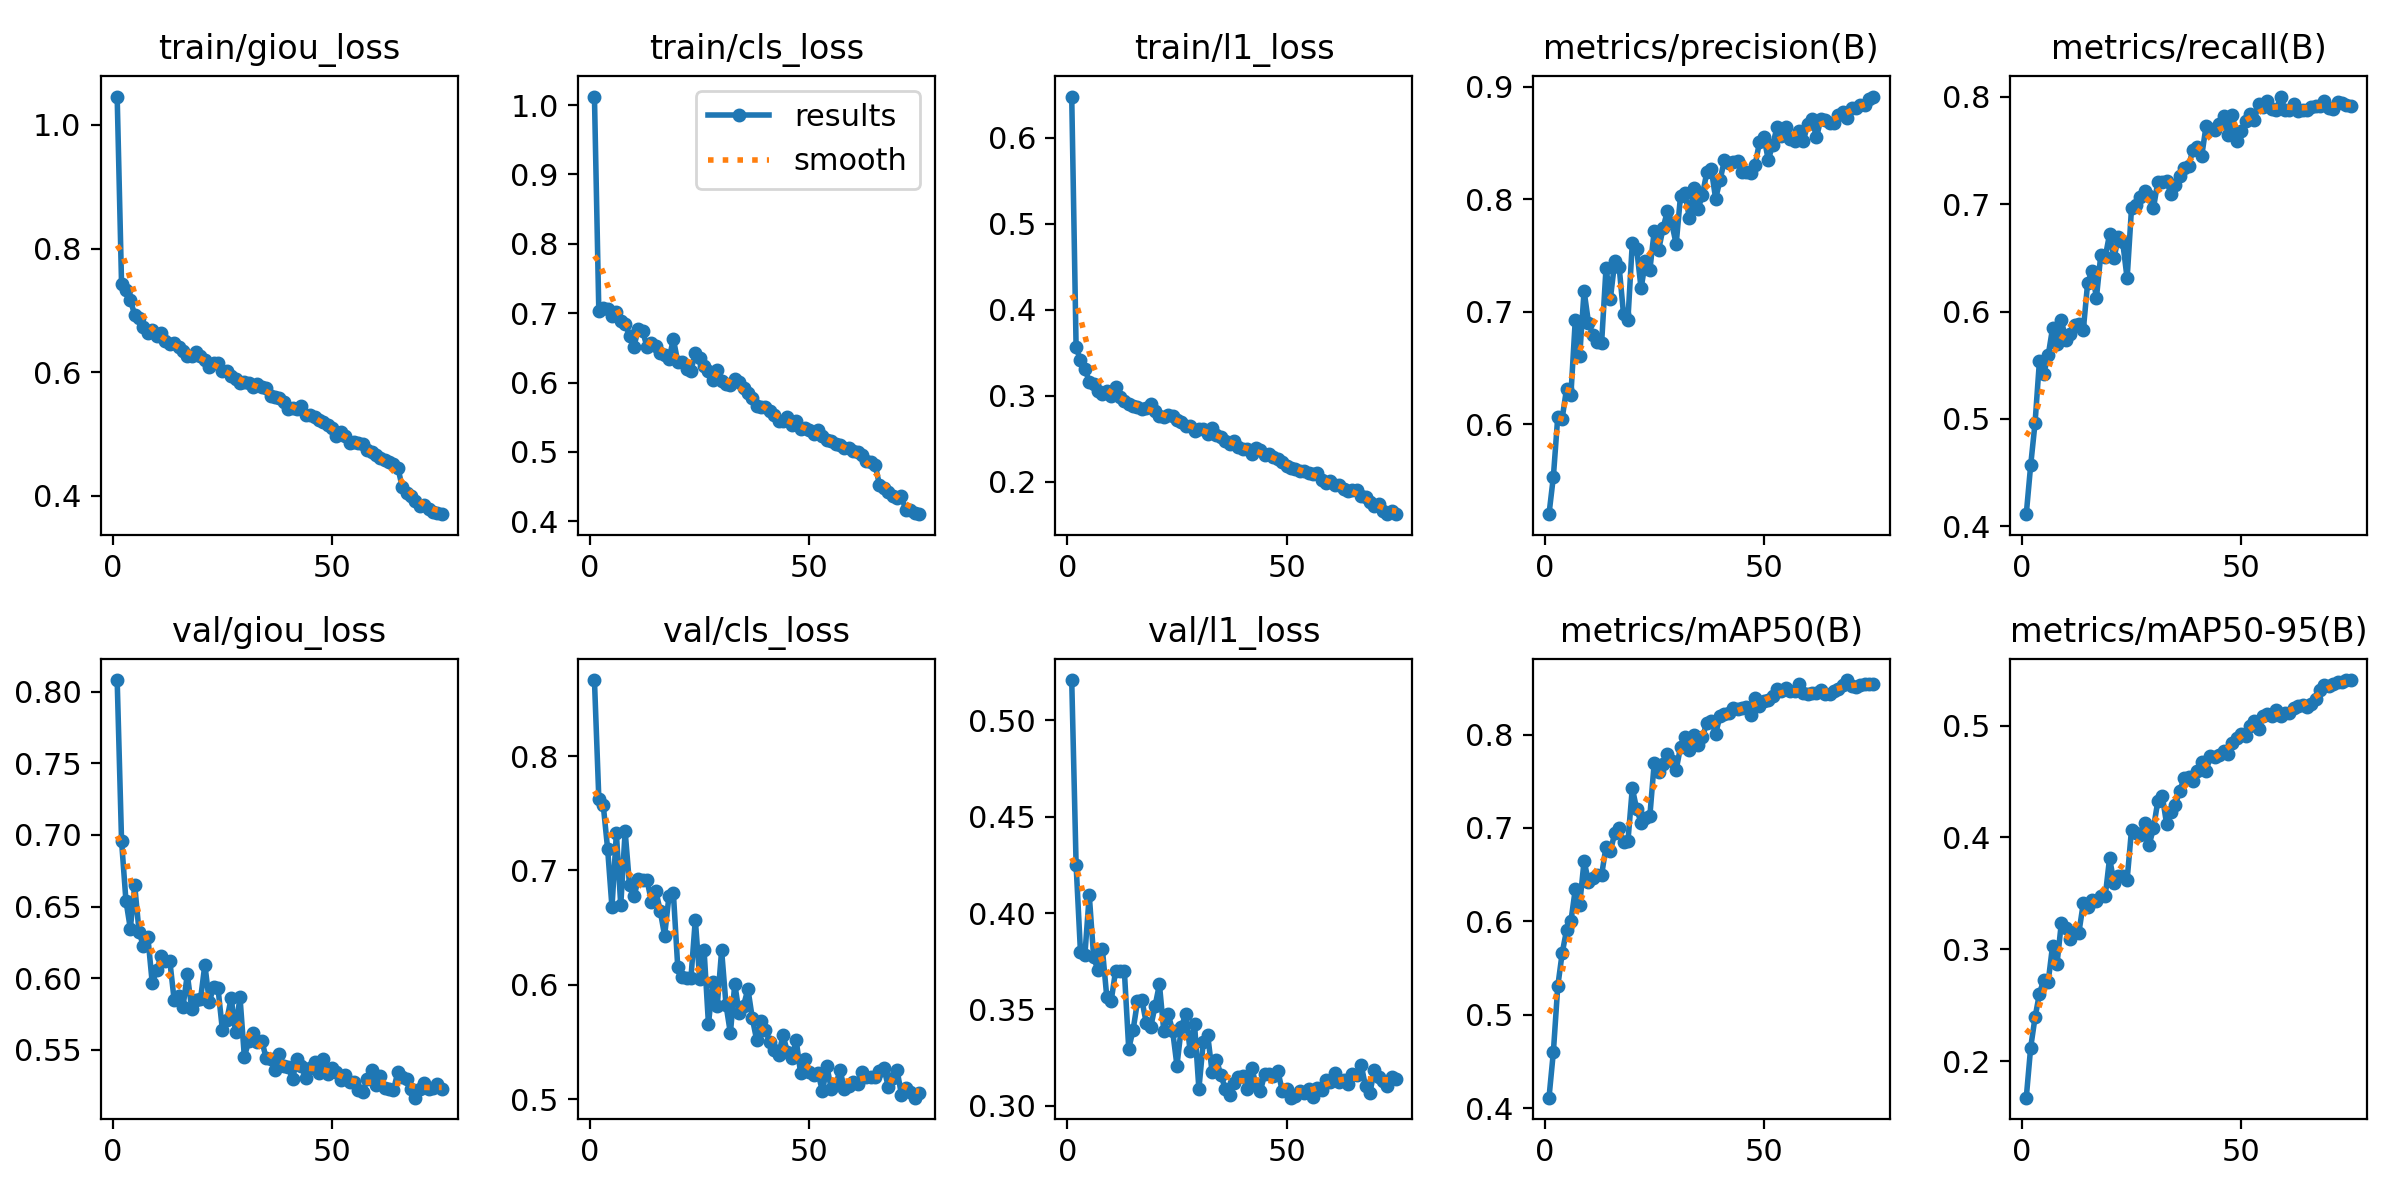

In [57]:
#Display Training Curves
from IPython.display import Image, display

display(Image(filename=save_dir/"results.png"))

In [58]:
results_csv = pd.read_csv(save_dir / "results.csv")

results_csv.tail()

,epoch,time,train/giou_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/giou_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2
70,71,25147.2,0.38497,0.43626,0.17456,0.88121,0.78846,0.85141,0.53746,0.52677,0.50418,0.31505,0.000152,0.000152,0.000152
71,72,25496.4,0.37799,0.41630,0.16585,0.88398,0.79489,0.85347,0.53906,0.52242,0.50976,0.31297,0.000126,0.000126,0.000126
72,73,25845.1,0.37398,0.41695,0.16311,0.88342,0.79375,0.85453,0.53894,0.52349,0.50654,0.31046,0.000099,0.000099,0.000099
73,74,26193.7,0.37240,0.41194,0.16574,0.88859,0.79231,0.85454,0.54035,0.52624,0.50147,0.31482,0.000073,0.000073,0.000073
74,75,26542.2,0.37037,0.41036,0.16259,0.89120,0.79152,0.85366,0.54064,0.52240,0.50594,0.31375,0.000046,0.000046,0.000046


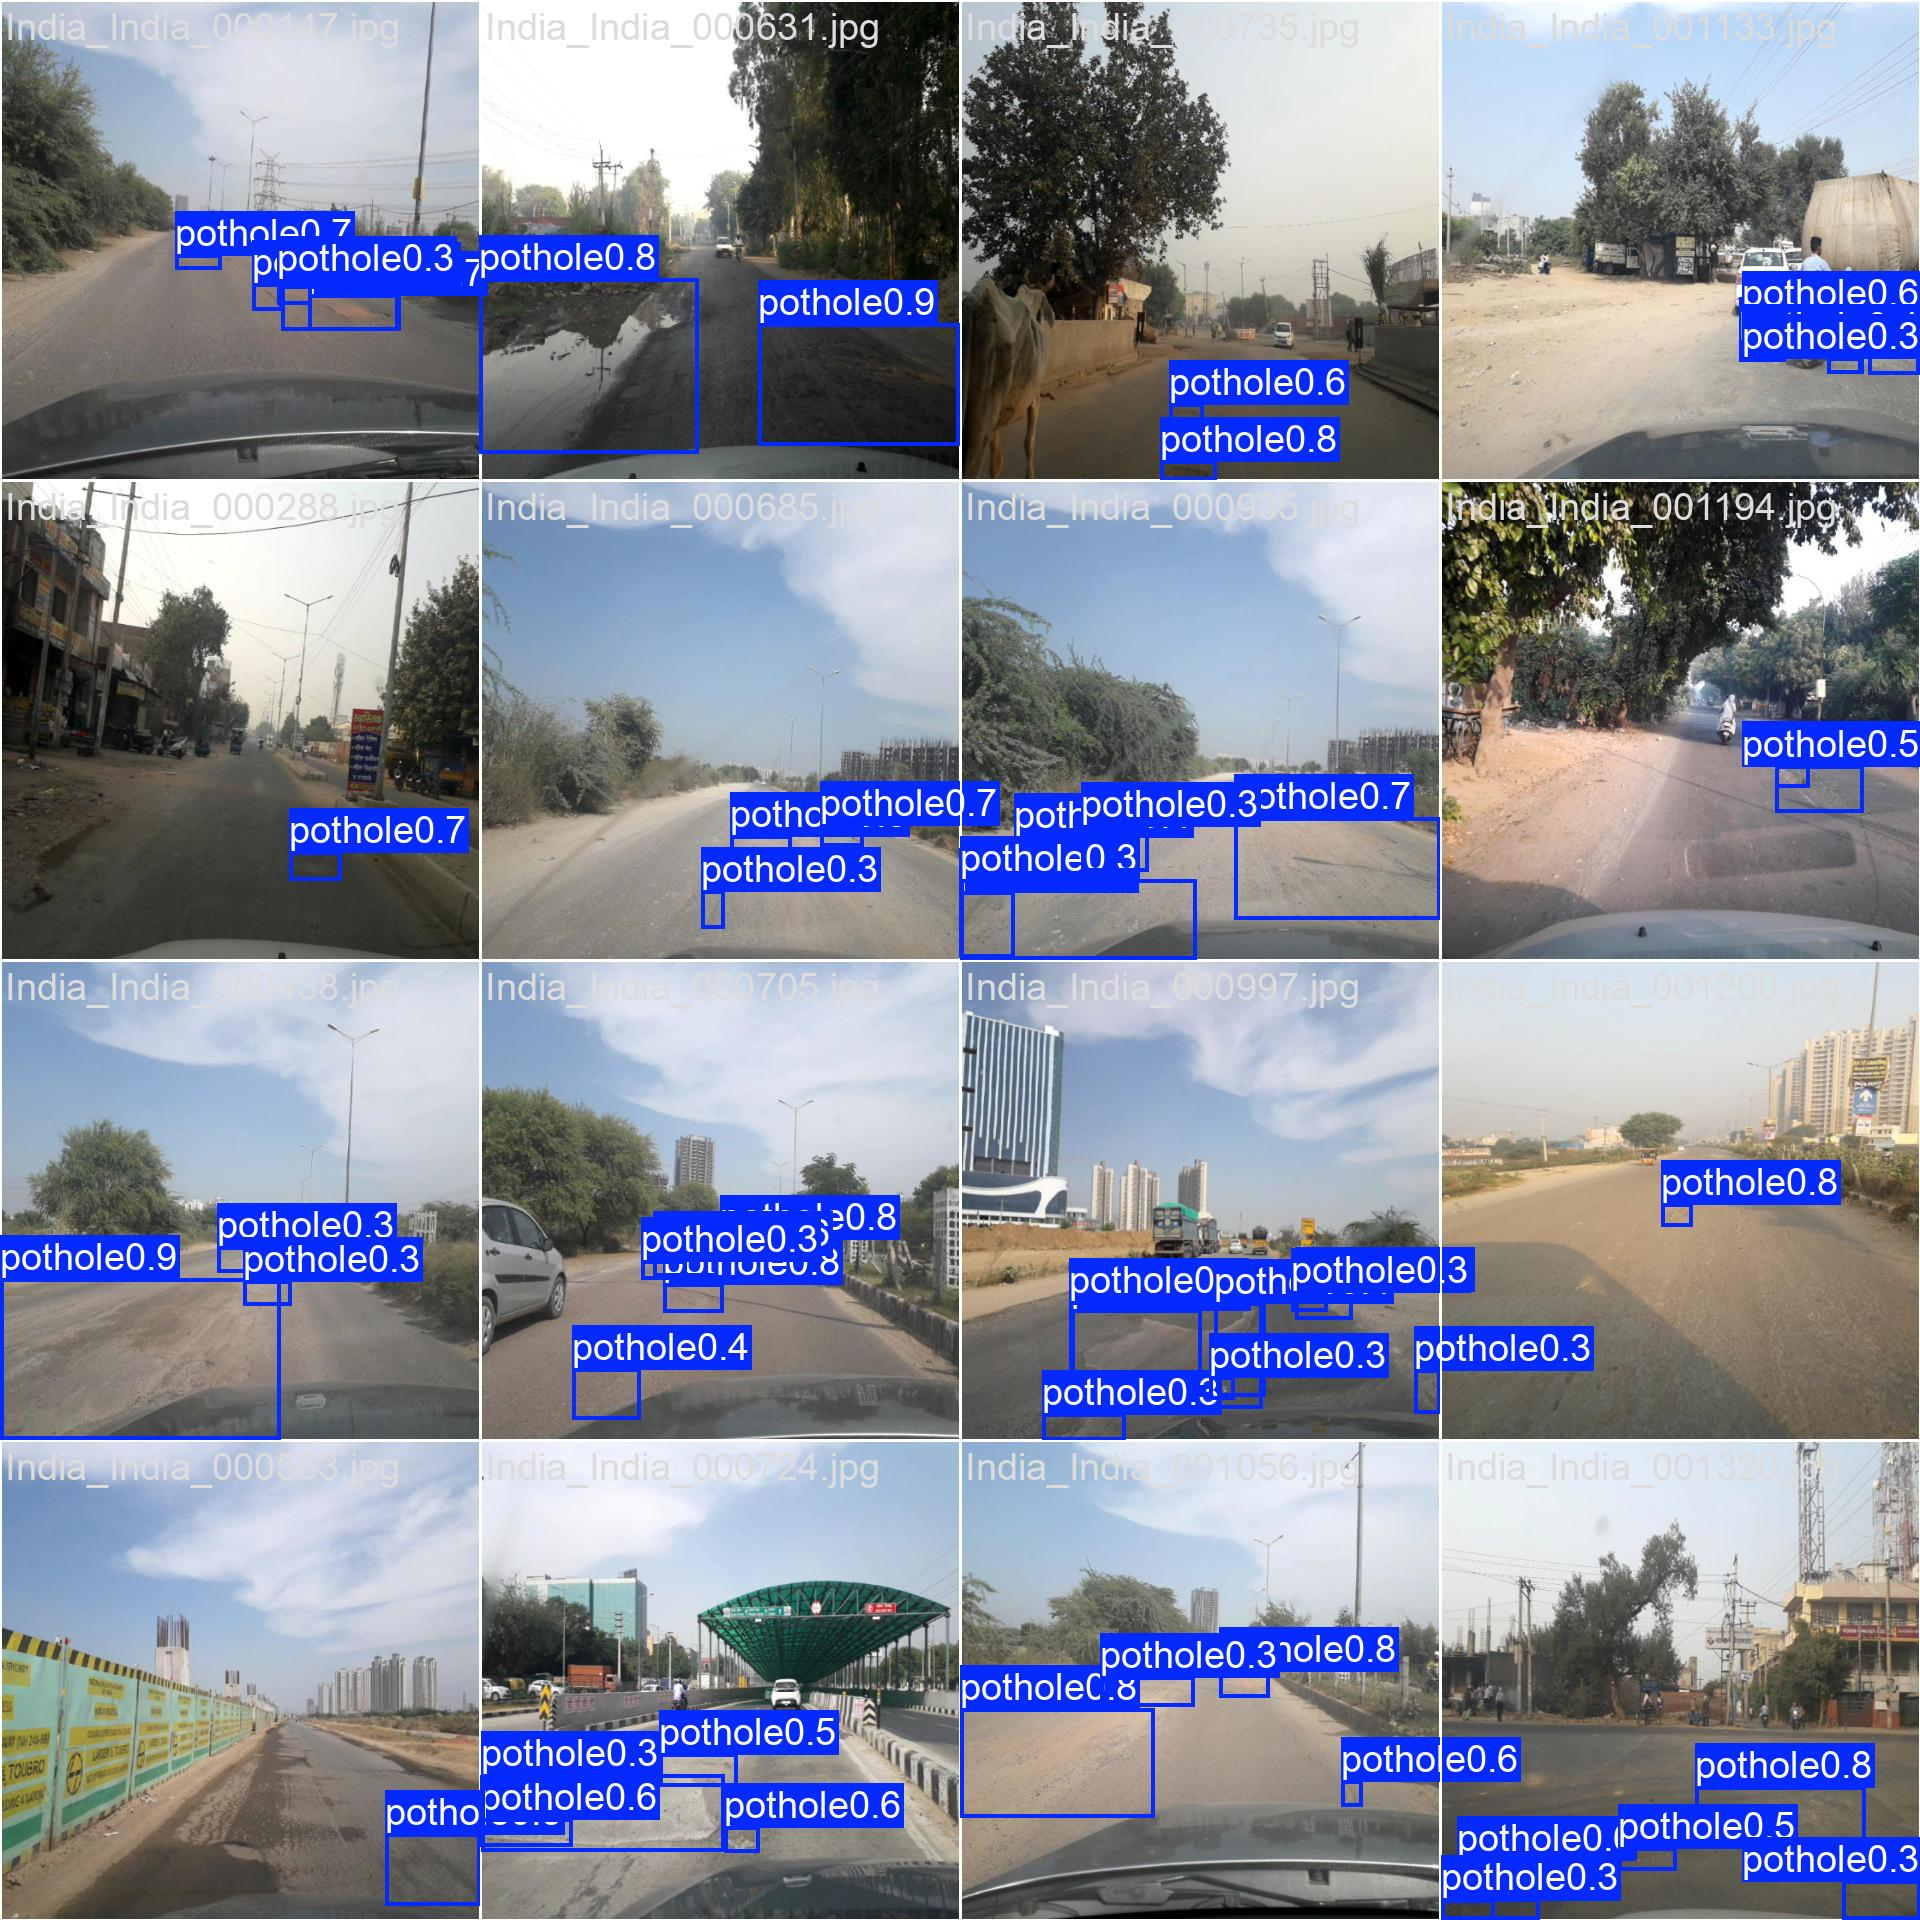

In [59]:
#Display Validation Results
display(Image(filename=save_dir/"val_batch0_pred.jpg"))

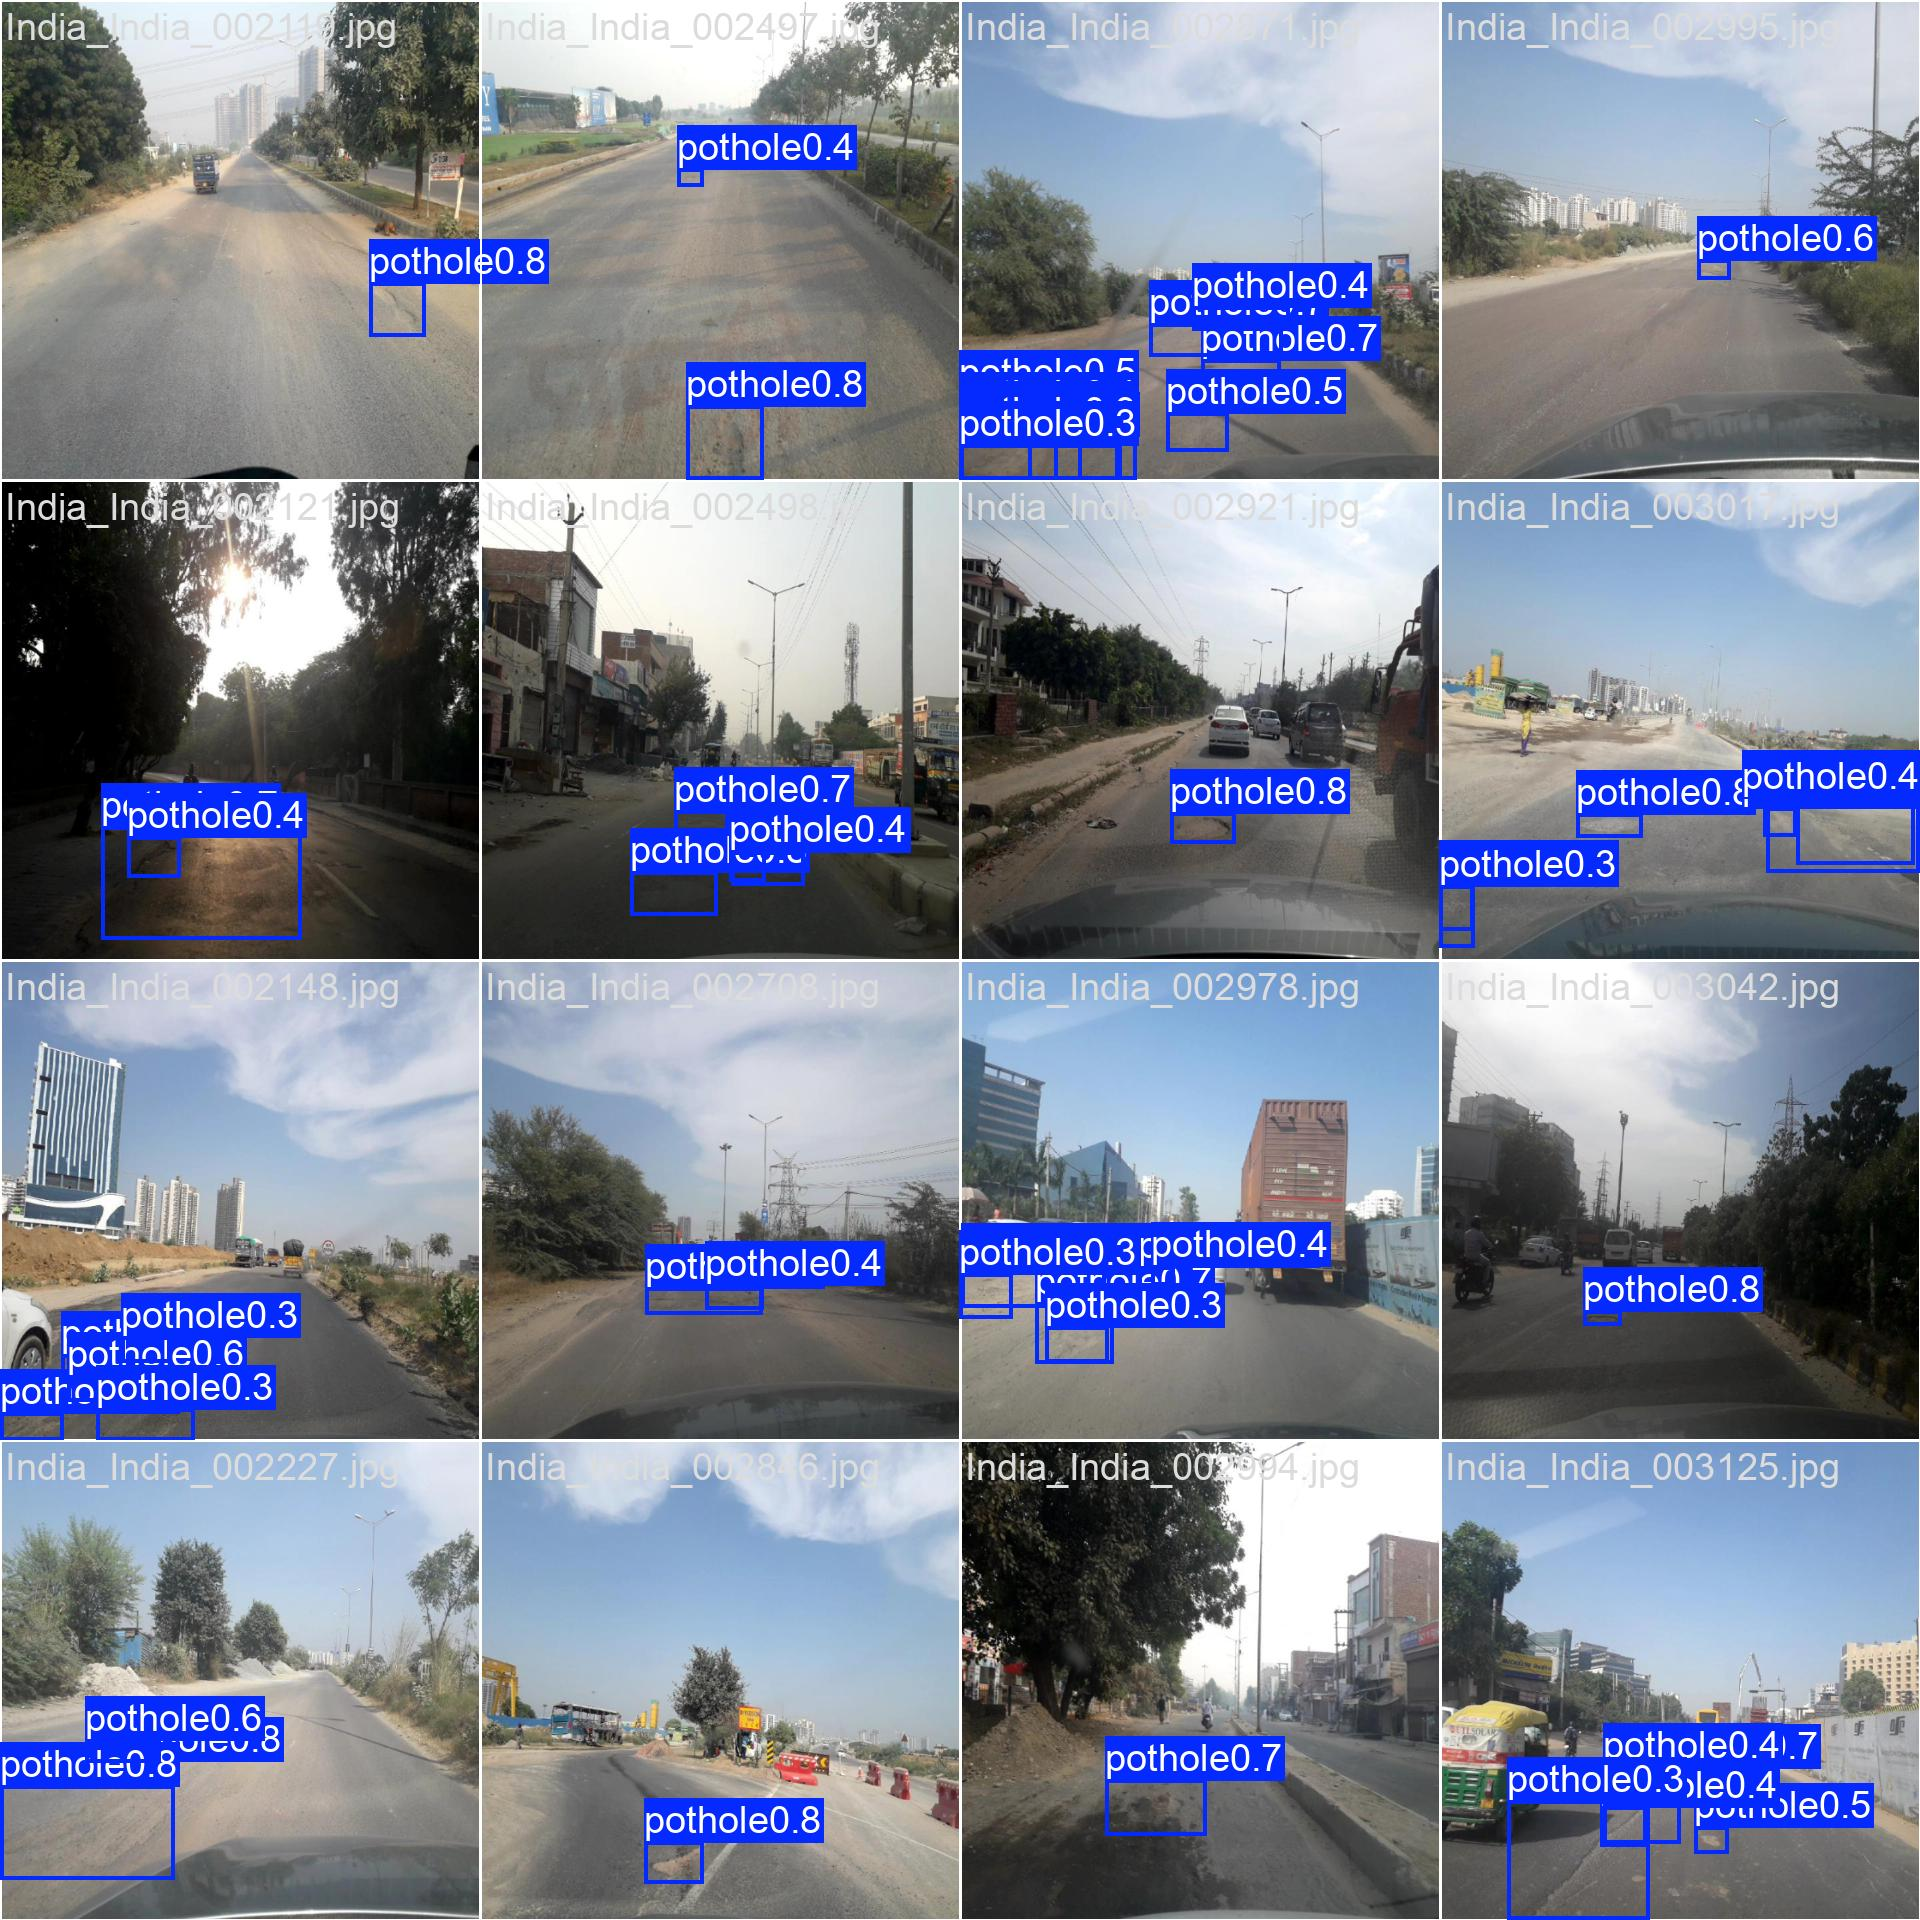

In [60]:
display(Image(filename=save_dir/"val_batch1_pred.jpg"))

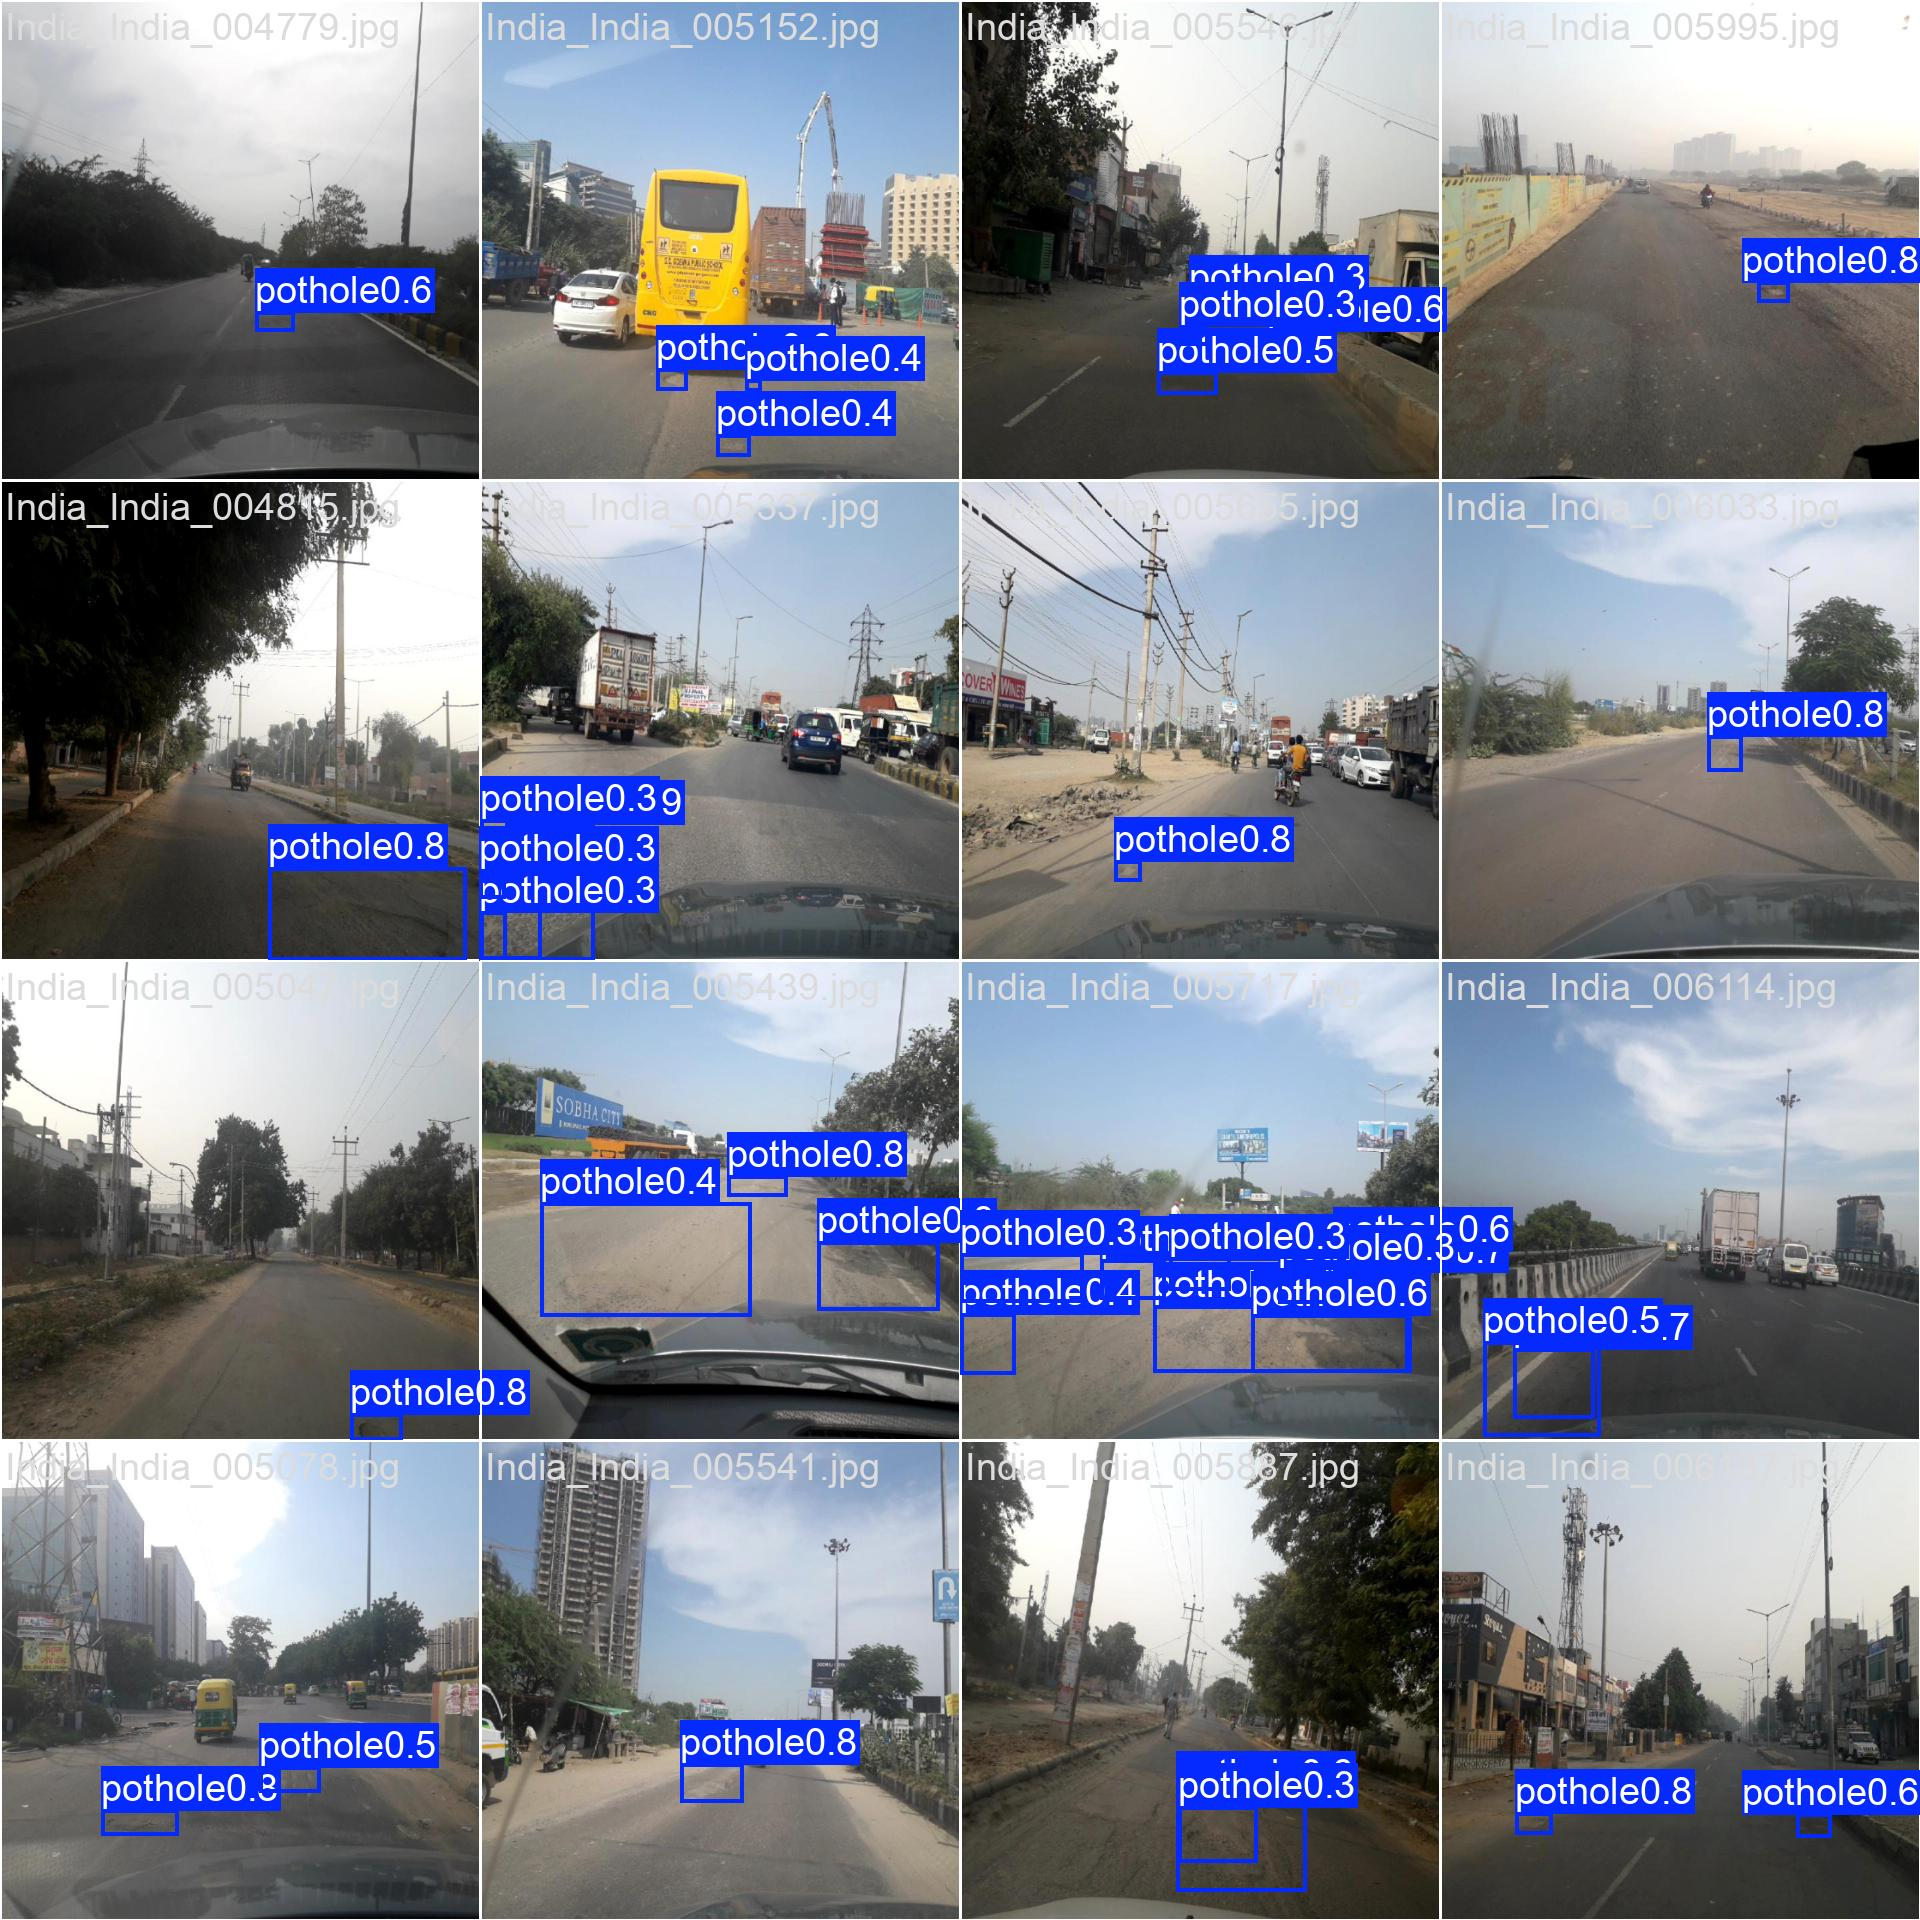

In [61]:
display(Image(filename=save_dir/"val_batch2_pred.jpg"))

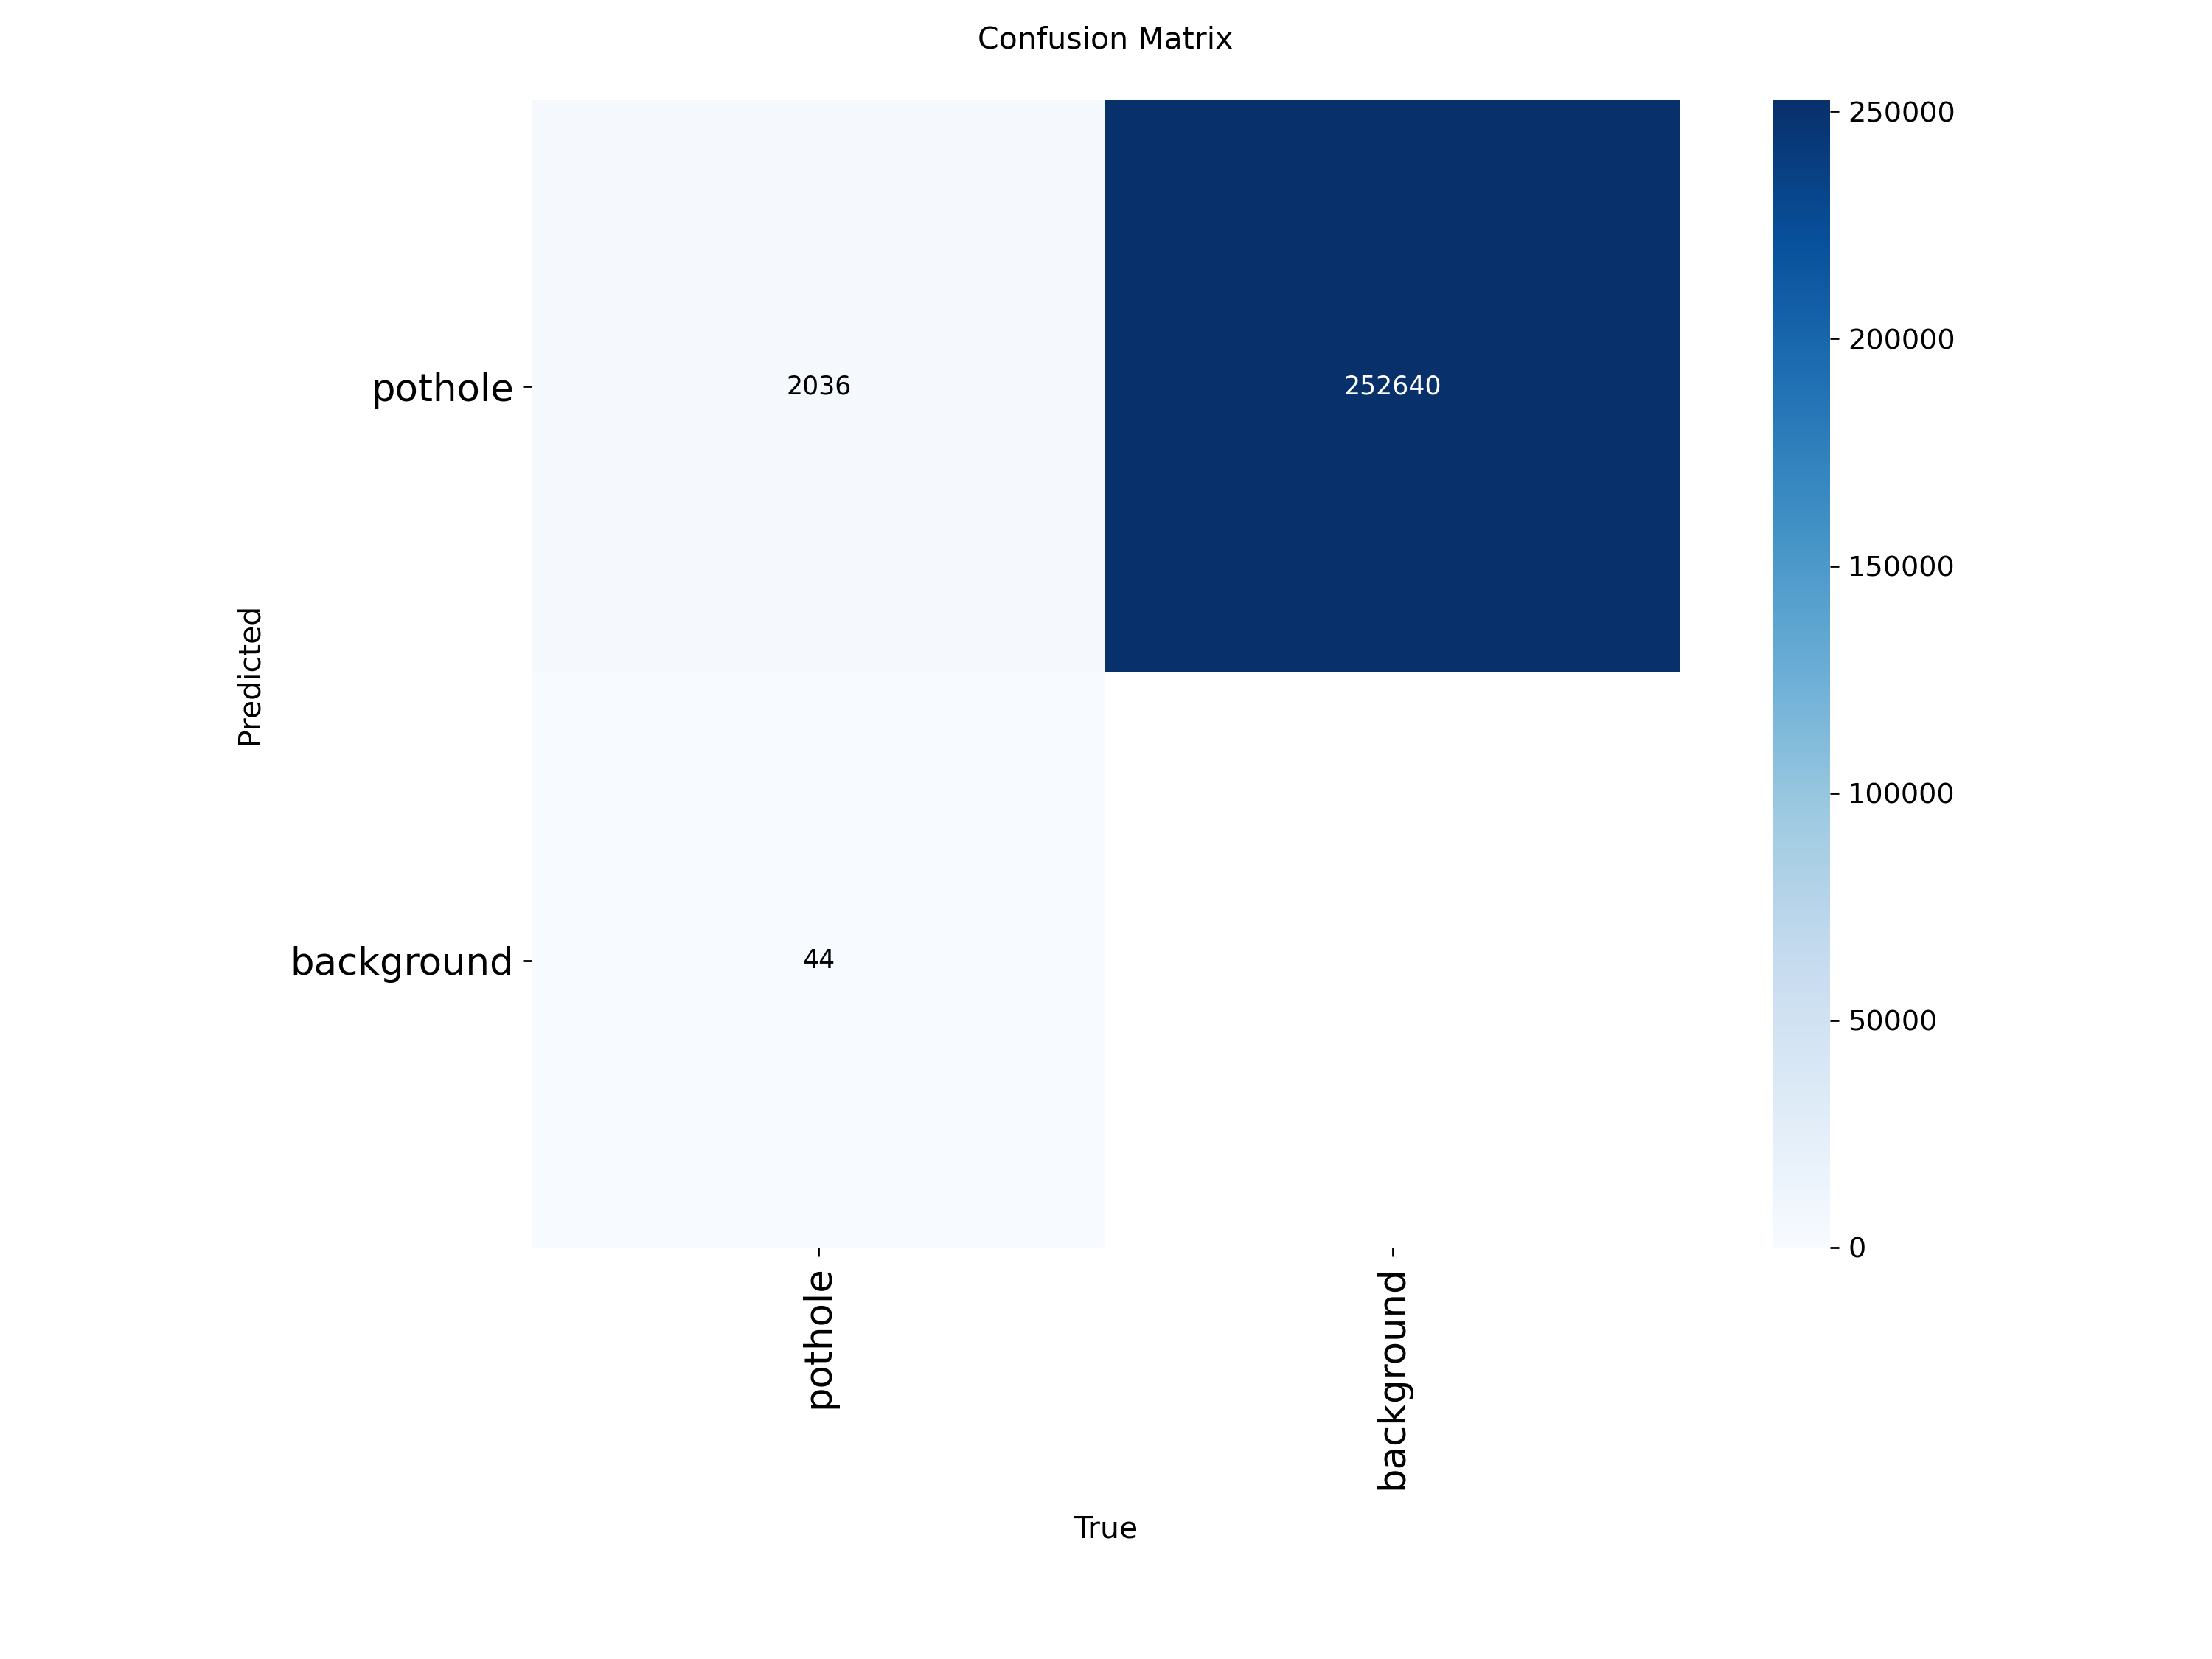

In [62]:
#Confusion Matrix
display(Image(filename=save_dir/"confusion_matrix.png"))

In [64]:
#To see what files are generated
from pathlib import Path

for f in sorted(Path(save_dir).glob("*")):
    print(f.name)

BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
experiment.json
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
train_batch20345.jpg
train_batch20346.jpg
train_batch20347.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


In [66]:
#Save Best Model
BEST_MODEL = save_dir / "weights" / "best.pt"

print(BEST_MODEL)

/kaggle/working/runs/detect/RTDETR_Pothole/Baseline_RTDETR_L-2/weights/best.pt


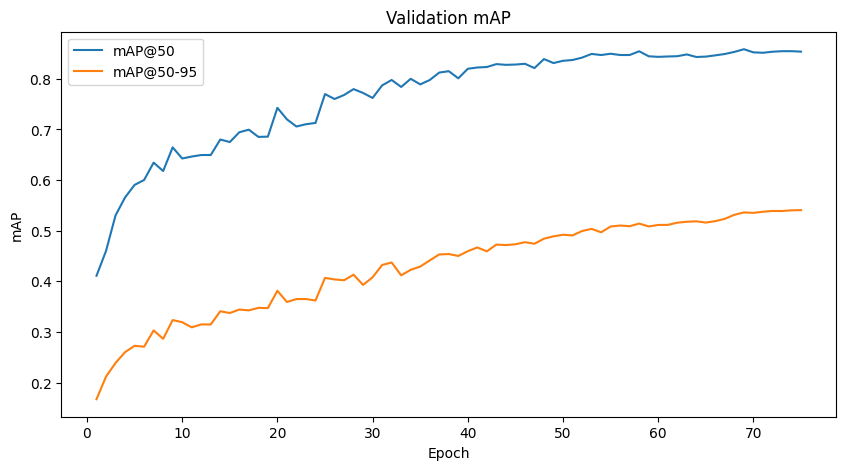

In [67]:
#Plot MAP
plt.figure(figsize=(10,5))

plt.plot(results_csv["epoch"], results_csv["metrics/mAP50(B)"], label="mAP@50")

plt.plot(results_csv["epoch"], results_csv["metrics/mAP50-95(B)"], label="mAP@50-95")

plt.xlabel("Epoch")

plt.ylabel("mAP")

plt.title("Validation mAP")

plt.legend()

plt.show()

In [70]:
results_csv.columns

Index(['epoch', 'time', 'train/giou_loss', 'train/cls_loss', 'train/l1_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/giou_loss', 'val/cls_loss', 'val/l1_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')

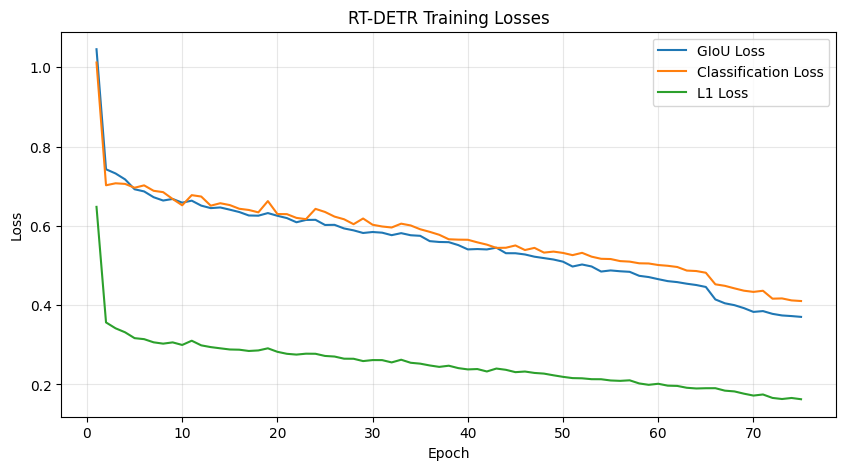

In [72]:
#Plot figures
plt.figure(figsize=(10,5))

plt.plot(results_csv["epoch"], results_csv["train/giou_loss"], label="GIoU Loss")
plt.plot(results_csv["epoch"], results_csv["train/cls_loss"], label="Classification Loss")
plt.plot(results_csv["epoch"], results_csv["train/l1_loss"], label="L1 Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RT-DETR Training Losses")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [73]:
#Display Best Matrics
best = results_csv.loc[
    results_csv["metrics/mAP50-95(B)"].idxmax()
]

best[
    [
        "epoch",
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)"
    ]
]

epoch                   75.00000
metrics/precision(B)     0.89120
metrics/recall(B)        0.79152
metrics/mAP50(B)         0.85366
metrics/mAP50-95(B)      0.54064
Name: 74, dtype: float64

In [74]:
save_dir = Path(
    "/kaggle/working/runs/detect/RTDETR_Pothole/Baseline_RTDETR_L-2"
)

In [79]:
from pathlib import Path

weights = Path("/kaggle/working/runs/detect/RTDETR_Pothole/Baseline_RTDETR_L-2/weights")

for f in weights.glob("epoch*.pt"):
    f.unlink()

print("Intermediate checkpoints removed.")

Intermediate checkpoints removed.


In [80]:
import shutil

save_dir = "/kaggle/working/runs/detect/RTDETR_Pothole/Baseline_RTDETR_L-2"

shutil.make_archive(
    "/kaggle/working/RTDETR_Baseline_Experiment",
    "zip",
    save_dir
)

print("Archive created.")

Archive created.


In [81]:
from pathlib import Path

zip_file = Path("/kaggle/working/RTDETR_Baseline_Experiment.zip")

print(zip_file.exists())
print(zip_file)
print(f"Size: {zip_file.stat().st_size / (1024*1024):.2f} MB")

True
/kaggle/working/RTDETR_Baseline_Experiment.zip
Size: 123.51 MB
